In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
data = pd.read_csv('лр3.csv', sep=",")
# Первые 5 строк датасета
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [101]:
from operator import itemgetter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math
from enum import Enum

class PredictionType(Enum):
    CLASSIFICATION = 1
    REGRESSION = 2

class SimpleKNN:

    def fit(self, X_train, y_train):
        """Метод обучения, запоминает обучающую выборку"""
        if hasattr(X_train, 'iloc'):
            self._X_train = X_train.values
        else:
            self._X_train = X_train

        if hasattr(y_train, 'iloc'):
            self._y_train = y_train.values
        else:
            self._y_train = y_train

    def eucl_dist(self, p: np.ndarray, q: np.ndarray) -> float:
        """Вычисление Евклидова расстояния"""
        return math.sqrt(sum([(pi - qi) ** 2 for pi, qi in zip(p, q)]))

    def predict_for_single_object(self, K: int, \
                prediction_type: PredictionType, \
                X_o: np.ndarray, \
                verbose=False) -> np.ndarray:
        """Предсказание для одного объекта"""
        neighbors_list = []

        for i in range(self._X_train.shape[0]):
            data_train_current_x = self._X_train[i]
            data_train_current_y = self._y_train[i]
            dist = self.eucl_dist(X_o, data_train_current_x)
            temp_res = (data_train_current_y, dist, data_train_current_x)
            neighbors_list.append(temp_res)

        neighbors_list_sorted = sorted(neighbors_list, key=itemgetter(1))

        if verbose:
            print()
            print('**************************************')
            print('Проверяемая точка: ', X_o)
            print('**************************************')
            print('Вывод отсортированного списка соседей:')
            dist_list = []
            for cur_y, cur_dist, temp_x in neighbors_list_sorted:
                print('Признаки={}, y={}, расстояние={:.2f}'.format(temp_x, cur_y, cur_dist))
                dist_list.append(cur_dist)
            print()
            print('Вывод расстояния для отсортированного списка соседей:')
            plt.plot(dist_list)
            plt.show()

        K_neighbors_list_sorted = neighbors_list_sorted[:K]

        if verbose:
            print('Вывод К ближайших соседей:')
            for cur_y, cur_dist, temp_x in K_neighbors_list_sorted:
                print('Признаки={}, y={}, расстояние={:.2f}'.format(temp_x, cur_y, cur_dist))

        if prediction_type == PredictionType.REGRESSION:
            arr = np.array([x for x,_,_ in K_neighbors_list_sorted])
            return np.mean(arr)
        elif prediction_type == PredictionType.CLASSIFICATION:
            k_y_list = [y for y,_,_ in K_neighbors_list_sorted]
            k_y_list_grouped_temp = np.unique(k_y_list, return_counts=True)
            k_y_list_grouped = [[key, cnt] for key, cnt in zip(k_y_list_grouped_temp[0], k_y_list_grouped_temp[1])]
            k_y_list_grouped_sorted = sorted(k_y_list_grouped, key=itemgetter(1), reverse=True)
            if verbose:
                print('Классы, соответствующие К ближайшим соседям:')
                for i in k_y_list_grouped_sorted:
                    print('класс={0}, количество элементов={1}'.format(i[0], i[1]))
            return k_y_list_grouped_sorted[0][0]
        else:
            raise Exception('Неизвестный тип предсказания')

    def predict(self, K: int, \
                prediction_type: PredictionType, \
                X_test, \
                verbose=False) -> np.ndarray:
        """Предсказание для всей тестовой выборки"""
        if hasattr(X_test, 'iloc'):
            X_test_values = X_test.values
        else:
            X_test_values = X_test

        predictions = []
        for i in range(X_test_values.shape[0]):
            data_test_current_x = X_test_values[i]
            pred = self.predict_for_single_object(
                K=K,
                prediction_type=prediction_type,
                X_o=data_test_current_x,
                verbose=verbose
            )
            predictions.append(pred)

        return np.array(predictions)

In [102]:
# проверим есть ли пропущенные значения
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [103]:
from sklearn.preprocessing import LabelEncoder
cat_enc = pd.DataFrame({'c1':data.T[0]})
cat_enc

,c1
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest
charges,16884.924


In [104]:
le_sex = LabelEncoder()
data['sex_kod'] = le_sex.fit_transform(data['sex'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


In [105]:
le_smoker = LabelEncoder()
data['smoker_kod'] = le_smoker.fit_transform(data['smoker'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod,smoker_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [106]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
region_encoded = ohe.fit_transform(data[['region']])

region_cols = [f'region_{cat}' for cat in ohe.categories_[0][1:]]
region_data = pd.DataFrame(region_encoded, columns=region_cols)

data = data.drop('region', axis=1)
data = pd.concat([data, region_data], axis=1)

data = data.drop(['sex', 'smoker'], axis=1)

data = data.rename(columns={
    'sex_kod': 'sex',
    'smoker_kod': 'smoker'
})

data.head()

,age,bmi,children,charges,sex,smoker,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1,0,1.0,0.0,0.0


In [107]:
from sklearn.model_selection import train_test_split

# Признаки (X) и целевая переменная (y)
X = data[['age', 'bmi', 'children', 'sex', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']]
y = data['charges']

# Разделение: 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% на тест
    random_state=42         # фиксируем random seed для воспроизводимости
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 1070 строк
Тестовая выборка: 268 строк


In [108]:
from sklearn.preprocessing import StandardScaler

# Признаки
feature_cols = ['age', 'bmi', 'children', 'sex', 'smoker',
                'region_northwest', 'region_southeast', 'region_southwest']

X = data[feature_cols]
y = data['charges']

# Разделяем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение KNN на масштабированных данных
knn = SimpleKNN()
knn.fit(X_train_scaled, y_train)

y_pred_scaled = knn.predict(K=5, prediction_type=PredictionType.REGRESSION,
                            X_test=X_test_scaled, verbose=False)

f"MAE после масштабирования: {mean_absolute_error(y_test, y_pred_scaled):.2f}"

'MAE после масштабирования: 3494.75'

In [109]:
# ОЦЕНКА КАЧЕСТВА
print("ОЦЕНКА МОДЕЛИ ПОСЛЕ МАСШТАБИРОВАНИЯ")
print(f"MAE: {mean_absolute_error(y_test, y_pred_scaled):.2f}")
print(f"R²: {r2_score(y_test, y_pred_scaled):.4f}")

print("\nПервые 10 предсказаний:")
for i in range(10):
    print(f"Реальное: {y_test.iloc[i]:.2f} → Предсказанное: {y_pred_scaled[i]:.2f}")

ОЦЕНКА МОДЕЛИ ПОСЛЕ МАСШТАБИРОВАНИЯ
MAE: 3494.75
R²: 0.8038

Первые 10 предсказаний:
Реальное: 9095.07 → Предсказанное: 8969.27
Реальное: 5272.18 → Предсказанное: 5637.41
Реальное: 29330.98 → Предсказанное: 25359.32
Реальное: 9301.89 → Предсказанное: 13092.75
Реальное: 33750.29 → Предсказанное: 21178.82
Реальное: 4536.26 → Предсказанное: 5838.49
Реальное: 2117.34 → Предсказанное: 3206.99
Реальное: 14210.54 → Предсказанное: 11676.03
Реальное: 3732.63 → Предсказанное: 4157.40
Реальное: 10264.44 → Предсказанное: 10037.90


In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Вычисляем метрики
mae = mean_absolute_error(y_test, y_pred_scaled)
mse = mean_squared_error(y_test, y_pred_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_scaled)

print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ KNN (K=5)")
print(f"MAE (средняя абсолютная ошибка):  {mae:.2f}")
print(f"MSE (средняя квадратичная ошибка): {mse:.2f}")
print(f"RMSE (корень из MSE):            {rmse:.2f}")
print(f"R² (коэффициент детерминации):    {r2:.4f}")

ОЦЕНКА КАЧЕСТВА МОДЕЛИ KNN (K=5)
MAE (средняя абсолютная ошибка):  3494.75
MSE (средняя квадратичная ошибка): 30459865.82
RMSE (корень из MSE):            5519.05
R² (коэффициент детерминации):    0.8038


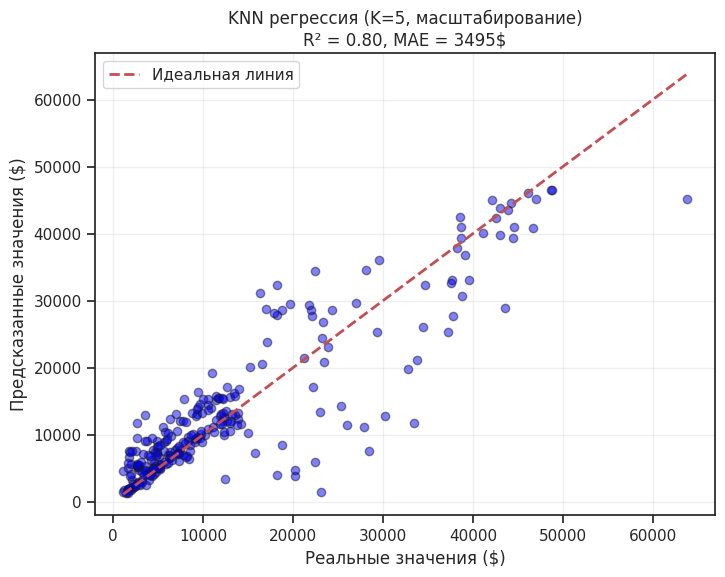

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_scaled, alpha=0.5, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title(f'KNN регрессия (K=5, масштабирование)\nR² = 0.80, MAE = 3495$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [112]:
#GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
import numpy as np
n_range = np.array(range(1, 31, 2))

tuned_parameters = [{'n_neighbors': n_range}]

clf_gs = GridSearchCV(
    KNeighborsRegressor(),
    tuned_parameters,
    cv=5,               #K-fold
    scoring='r2'
)

clf_gs.fit(X_train_scaled, y_train)
print(f"Лучший K: {clf_gs.best_params_['n_neighbors']}")
print(f"Лучший R² на кросс-валидации: {clf_gs.best_score_:.4f}")

y_pred_best = clf_gs.best_estimator_.predict(X_test_scaled)
print(f"R² на тестовой выборке: {r2_score(y_test, y_pred_best):.4f}")
print(f"MAE на тестовой выборке: ${mean_absolute_error(y_test, y_pred_best):.2f}")


Лучший K: 9
Лучший R² на кросс-валидации: 0.7735
R² на тестовой выборке: 0.7984
MAE на тестовой выборке: $3470.61


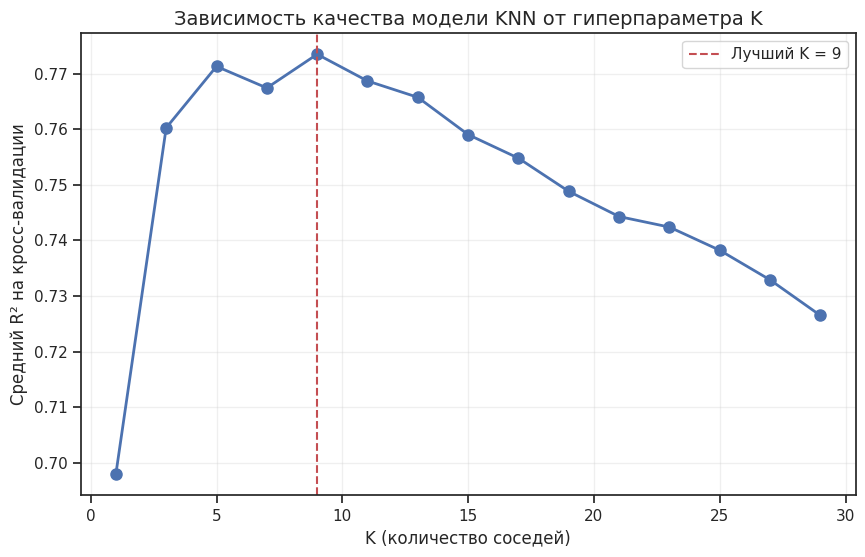

In [113]:
plt.figure(figsize=(10, 6))
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'], 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (количество соседей)', fontsize=12)
plt.ylabel('Средний R² на кросс-валидации', fontsize=12)
plt.title('Зависимость качества модели KNN от гиперпараметра K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=clf_gs.best_params_['n_neighbors'], color='r', linestyle='--',
            label=f'Лучший K = {clf_gs.best_params_["n_neighbors"]}')
plt.legend()
plt.show()

In [114]:
#RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, ShuffleSplit
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt

n_range = np.array(range(1, 31, 2))  # K = 1, 3, 5, ..., 29
tuned_parameters = [{'n_neighbors': n_range}]

ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

clf_rs = RandomizedSearchCV(
    KNeighborsRegressor(),
    tuned_parameters,
    cv=ss,                     # ShuffleSplit
    scoring='r2',
    n_iter=15,
    random_state=42
)

# Обучение на масштабированных данных
clf_rs.fit(X_train_scaled, y_train)

print(f"Лучший K (RandomizedSearchCV): {clf_rs.best_params_['n_neighbors']}")
print(f"Лучший R² на кросс-валидации: {clf_rs.best_score_:.4f}")

Лучший K (RandomizedSearchCV): 9
Лучший R² на кросс-валидации: 0.7857


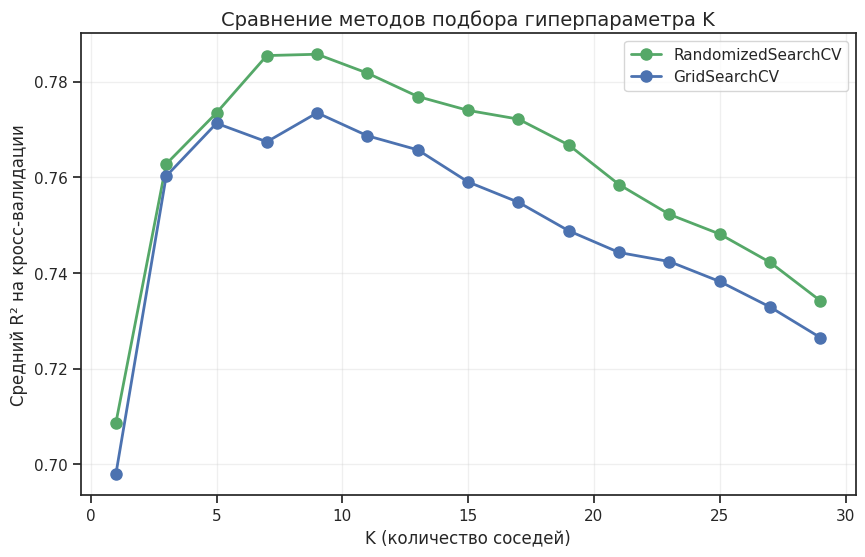

In [115]:
plt.figure(figsize=(10, 6))

# График для RandomizedSearchCV
plt.plot(n_range, clf_rs.cv_results_['mean_test_score'], 'go-', linewidth=2, markersize=8, label='RandomizedSearchCV')

# График для GridSearchCV
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'], 'bo-', linewidth=2, markersize=8, label='GridSearchCV')

plt.xlabel('K (количество соседей)', fontsize=12)
plt.ylabel('Средний R² на кросс-валидации', fontsize=12)
plt.title('Сравнение методов подбора гиперпараметра K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [116]:
# Предсказание лучшей модели
y_pred_best_rs = clf_rs.best_estimator_.predict(X_test_scaled)

print(f"R² на тесте:  {r2_score(y_test, y_pred_best_rs):.4f}")
print(f"MAE на тесте: ${mean_absolute_error(y_test, y_pred_best_rs):.2f}")

R² на тесте:  0.7984
MAE на тесте: $3470.61


In [117]:
#сравнение исходной и оптимальной моделей

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Метрики для K=5
mae_k5 = 3494.75
r2_k5 = 0.8038

# Метрики для K=9 (из GridSearchCV)
mae_k9 = 3470.61
r2_k9 = 0.7984

# Сравнительная таблица
comparison = pd.DataFrame({
    'Модель': ['KNN (K=5, произвольный)', 'KNN (K=9, оптимальный)'],
    'MAE ($)': [mae_k5, mae_k9],
    'R²': [r2_k5, r2_k9]
})


print("СРАВНЕНИЕ МОДЕЛЕЙ ПОСЛЕ МАСШТАБИРОВАНИЯ")

print(comparison.to_string(index=False))


print(f"Оптимальный K = 9")
print(f"Улучшение MAE: ${mae_k5 - mae_k9:.2f} ({(1 - mae_k9/mae_k5)*100:.1f}%)")
print(f"R² изменился с {r2_k5:.4f} на {r2_k9:.4f}")

СРАВНЕНИЕ МОДЕЛЕЙ ПОСЛЕ МАСШТАБИРОВАНИЯ
                 Модель  MAE ($)     R²
KNN (K=5, произвольный)  3494.75 0.8038
 KNN (K=9, оптимальный)  3470.61 0.7984
Оптимальный K = 9
Улучшение MAE: $24.14 (0.7%)
R² изменился с 0.8038 на 0.7984
